In [15]:
!pip install wordcloud

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67529 entries, 0 to 67528
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  67529 non-null  int64  
 1   company                     67529 non-null  object 
 2   pros                        67529 non-null  object 
 3   cons                        67529 non-null  object 
 4   overall-ratings             67529 non-null  int64  
 5   work-balance-stars          67529 non-null  float64
 6   culture-values-stars        67529 non-null  int64  
 7   career-opportunities-stars  67529 non-null  float64
 8   comp-benefit-stars          67529 non-null  float64
 9   senior-management-stars     67529 non-null  float64
dtypes: float64(4), int64(3), object(3)
memory usage: 5.2+ MB


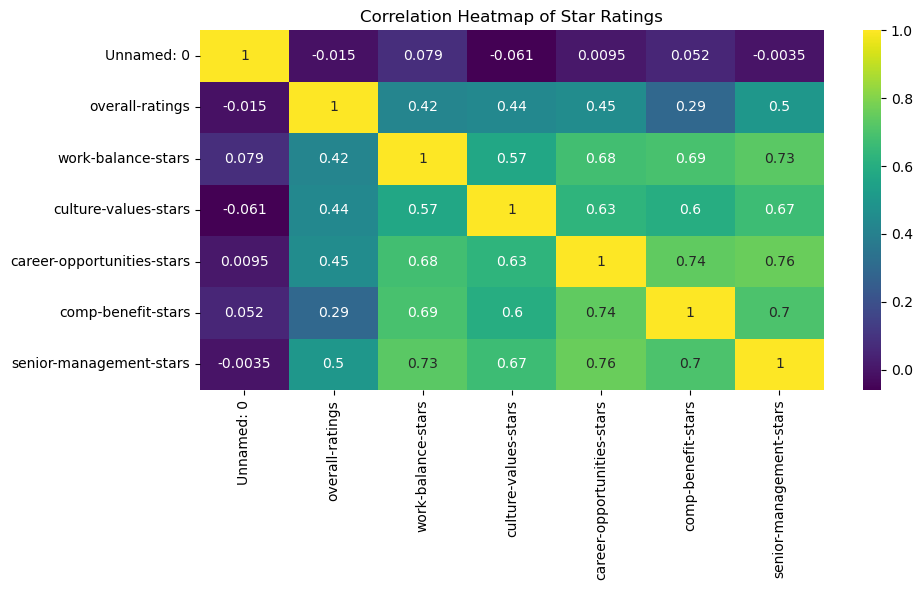

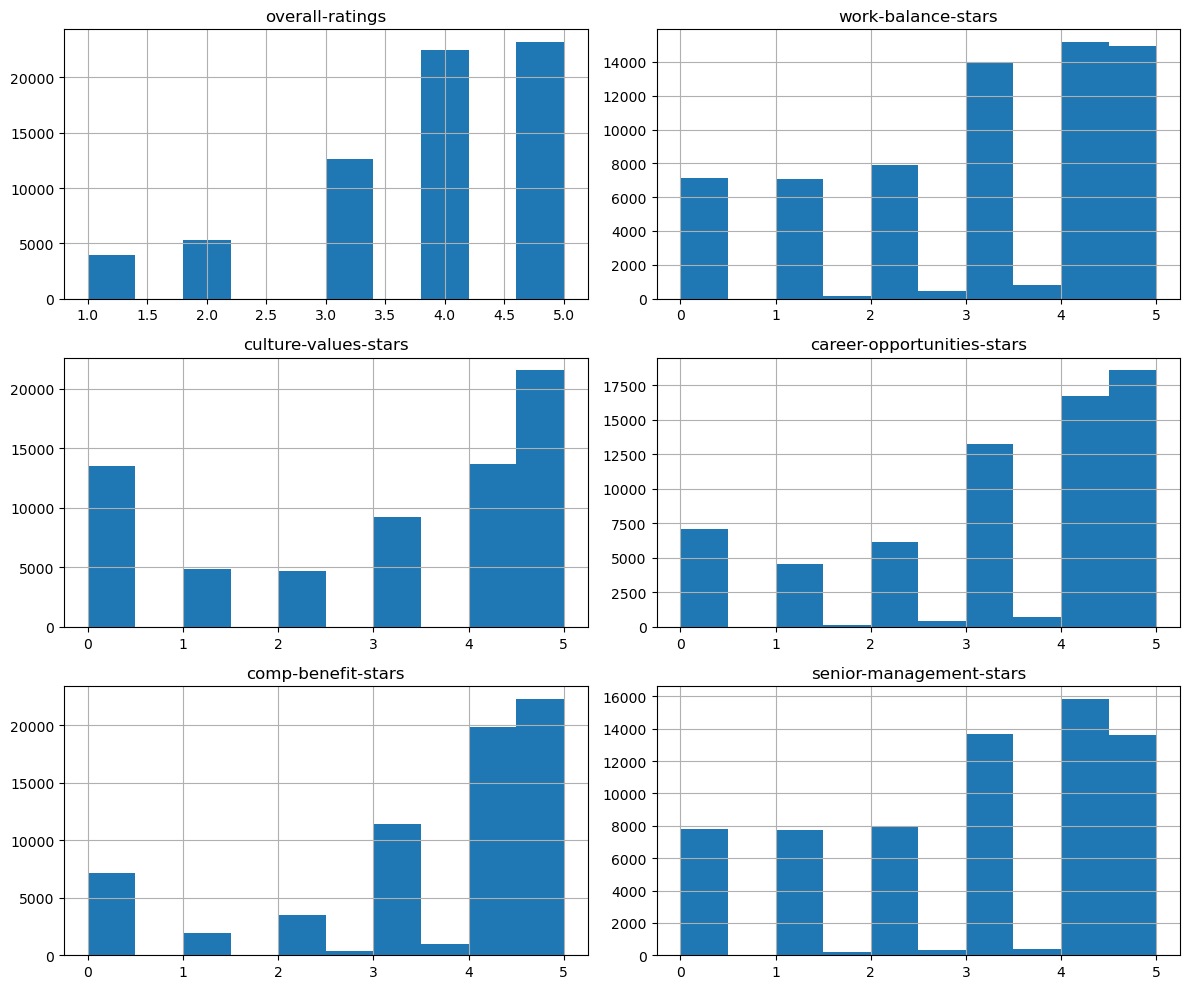

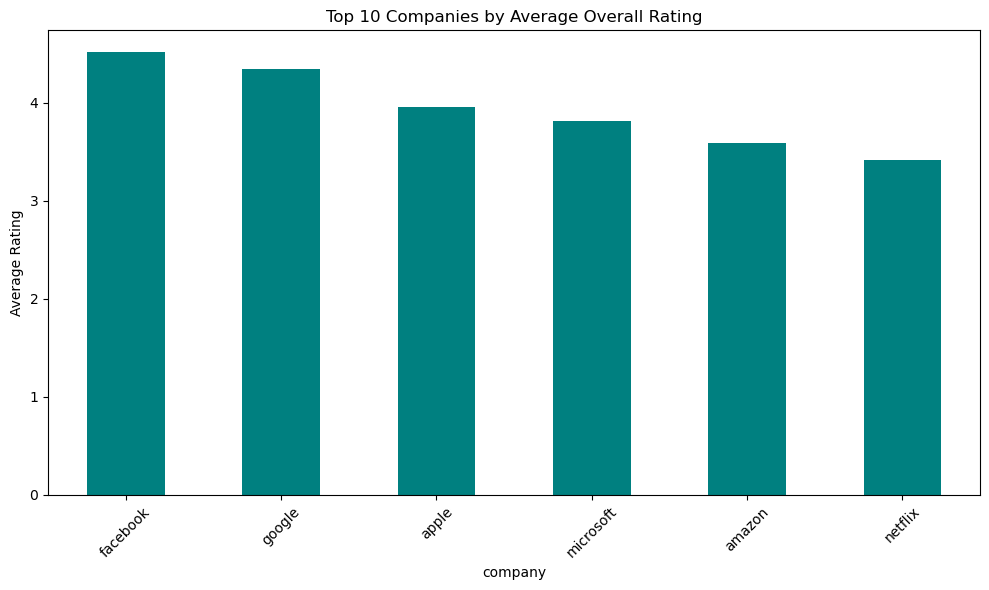

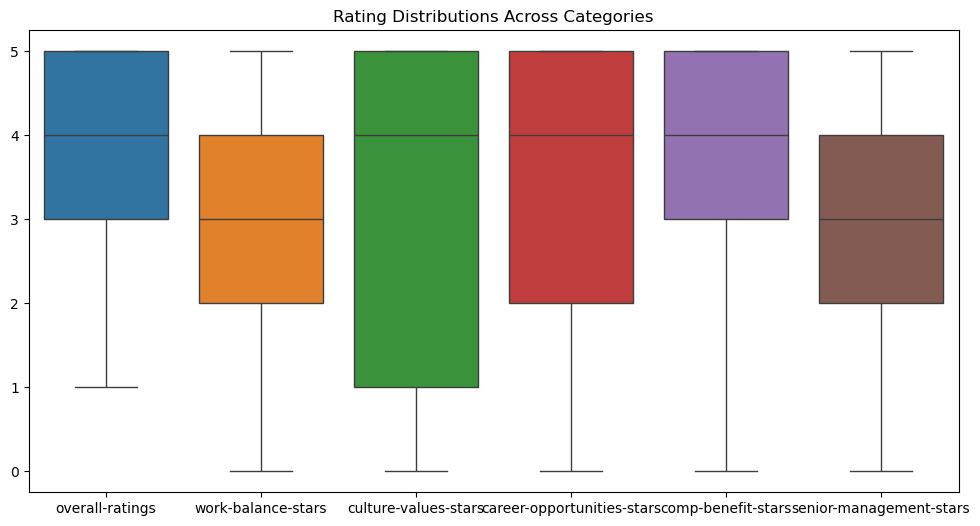

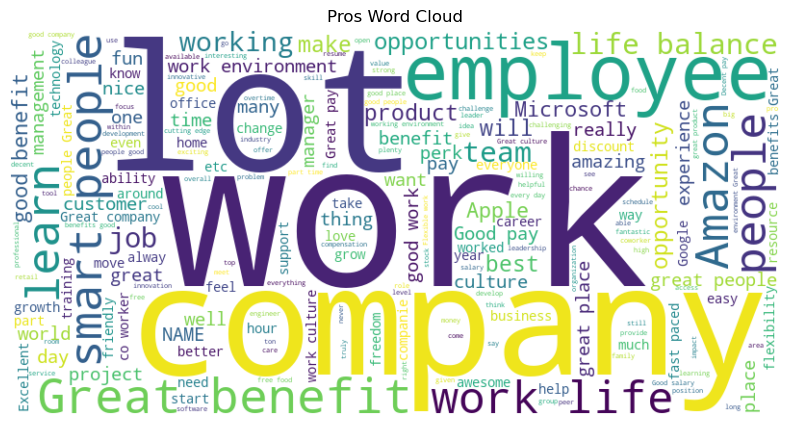

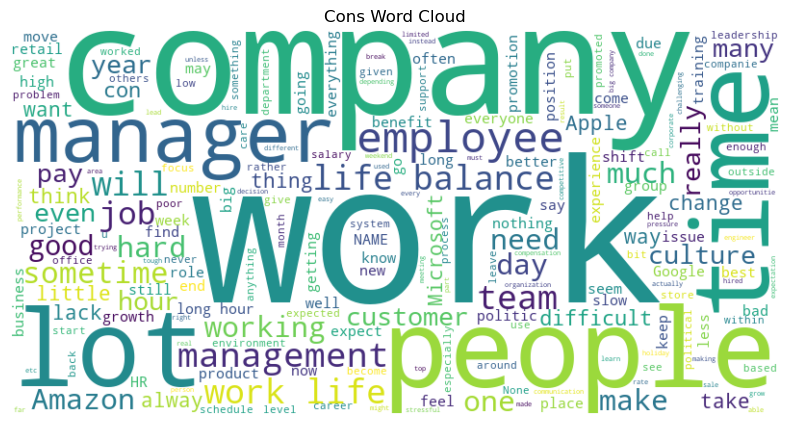

In [17]:
import pandas as pd
df = pd.read_csv(r"C:\Users\USER\Desktop\employee_reviews.csv", encoding='latin1', encoding_errors='ignore')

#analysing the dataset
df.head()
df.info()
df.describe()

#the dataset is already cleaned so i will start with the visualisations.
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df.select_dtypes(include=['int64', 'float64'])

save_dir = "C:/Users/USER/Desktop/TechProject/static/"
#corelation heatmap-> will be a help in the regression model
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="viridis")
plt.title("Correlation Heatmap of Star Ratings")
plt.tight_layout()
plt.savefig(save_dir + "correlation_heatmap.png")
plt.show()

#distribution of each star rating-> shows rating patters across categories
star_cols = [
    'overall-ratings',
    'work-balance-stars',
    'culture-values-stars',
    'career-opportunities-stars',
    'comp-benefit-stars',
    'senior-management-stars'
]

df[star_cols].hist(figsize=(12,10), bins=10)
plt.tight_layout()
plt.savefig(save_dir + "star_distributions.png")
plt.show()

#average rating per comapny -> will justify classification ad insights
top10 = (
    df.groupby("company")["overall-ratings"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top10.plot(kind='bar', color='teal')
plt.title("Top 10 Companies by Average Overall Rating")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(save_dir + "top10_companies.png")
plt.show()

#boxplot for variation in Ratings
plt.figure(figsize=(12,6))
sns.boxplot(data=df[star_cols])
plt.title("Rating Distributions Across Categories")
plt.tight_layout
plt.savefig(save_dir + "rating_boxplot.png")
plt.show()

#sentiment word clouds
from wordcloud import WordCloud

# PROS
pros_text = " ".join(df['pros'].dropna().astype(str).tolist())
wordcloud_pros = WordCloud(width=800, height=400, background_color='white').generate(pros_text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_pros, interpolation='bilinear')
plt.axis("off")
plt.title("Pros Word Cloud")
plt.savefig(save_dir + "pros_wordcloud.png")
plt.show()

# CONS
cons_text = " ".join(df['cons'].dropna().astype(str).tolist())
wordcloud_cons = WordCloud(width=800, height=400, background_color='white').generate(cons_text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_cons, interpolation='bilinear')
plt.axis("off")
plt.title("Cons Word Cloud")
plt.savefig(save_dir + "cons_wordcloud.png")
plt.show()


Mean Squared Error: 0.9300890113382223
R² Score: 0.3119849644347338


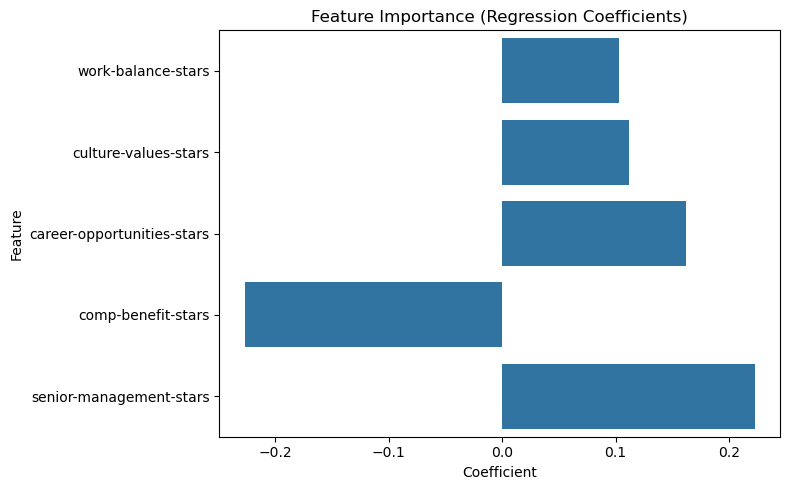

In [19]:
#i will now train the regression model to see which factors affect the overall-ratings the most
# -------------------------
# REGRESSION MODEL
# Predicting overall ratings using star categories
# -------------------------

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Load the Dataset
# Feature columns (stars given by employees)
features = [
    "work-balance-stars",
    "culture-values-stars",
    "career-opportunities-stars",
    "comp-benefit-stars",
    "senior-management-stars"
]

X = df[features]

# Target variable (what we're predicting)
y = df["overall-ratings"]

# 2. Split Into Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Train Linear Regression Model
reg = LinearRegression()
reg.fit(X_train, y_train)

# 4. Evaluate Model
y_pred = reg.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

 #5. Feature Importance Visualization
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": reg.coef_
})

plt.figure(figsize=(8, 5))
sns.barplot(x="Coefficient", y="Feature", data=coefficients)
plt.title("Feature Importance (Regression Coefficients)")
plt.tight_layout()

#for flask results page
plt.savefig("C:/Users/USER/Desktop/TechProject/static/regression_importance.png")
plt.show()

import pickle

# Save regression model
with open("C:/Users/USER/Desktop/TechProject/regression_model.pkl", "wb") as f:
    pickle.dump(reg, f)


Accuracy: 0.4444691248334074

Classification Report:
               precision    recall  f1-score   support

      amazon       0.46      0.78      0.58      5286
       apple       0.36      0.23      0.28      2590
    facebook       0.00      0.00      0.00       318
      google       0.23      0.05      0.08      1564
   microsoft       0.46      0.35      0.39      3586
     netflix       0.13      0.04      0.06       162

    accuracy                           0.44     13506
   macro avg       0.27      0.24      0.23     13506
weighted avg       0.40      0.44      0.39     13506



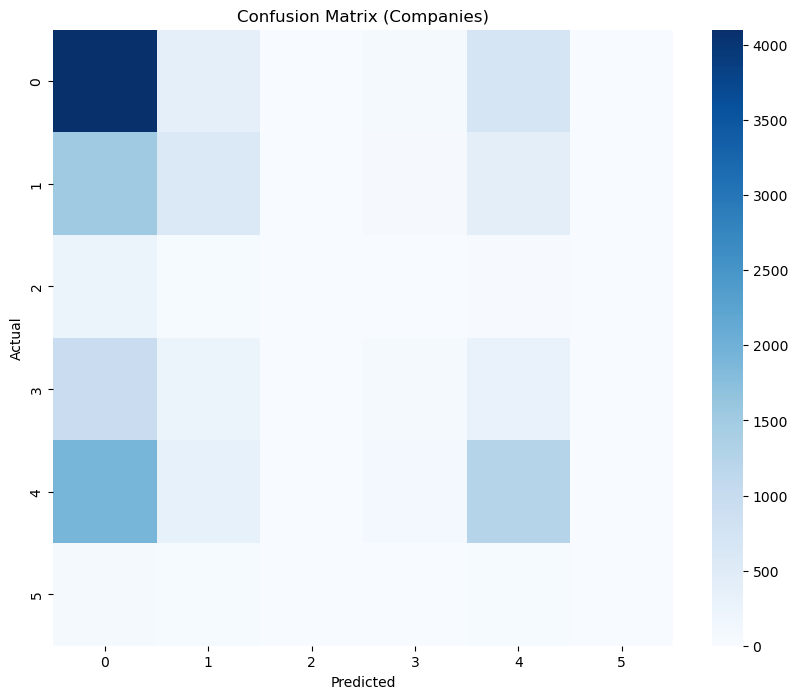

In [21]:
#i will now train the classification model which is the core of the project
#it will tell the user which company is fit for them based on their ratings

# Predicting best company based on star ratings
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle

# Features: employee star ratings
features = [
    "work-balance-stars",
    "culture-values-stars",
    "career-opportunities-stars",
    "comp-benefit-stars",
    "senior-management-stars"
]

X = df[features]

# Target: company
y = df["company"]

#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#Train Random Forest Classifier
clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

#Evaluate Model
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

#confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=False, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Companies)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

#Save Model for Flask
with open("C:/Users/USER/Desktop/TechProject/classification_model.pkl", "wb") as f:
    pickle.dump(clf, f)


In [22]:
!pip install nltk


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


                                                pros pros_sentiment  \
0                      People are smart and friendly       Positive   
1  1) Food, food, food. 15+ cafes on main campus ...       Positive   
2  * If you're a software engineer, you're among ...       Positive   
3  You can't find a more well-regarded company th...       Positive   
4  Google is a world of its own. At every other c...       Positive   

                                                cons cons_sentiment  
0                 Bureaucracy is slowing things down        Neutral  
1  1) Work/life balance. What balance? All those ...       Positive  
2  * It *is* becoming larger, and with it comes g...       Positive  
3  I live in SF so the commute can take between 1...       Positive  
4  If you don't work in MTV (HQ), you will be giv...       Positive  


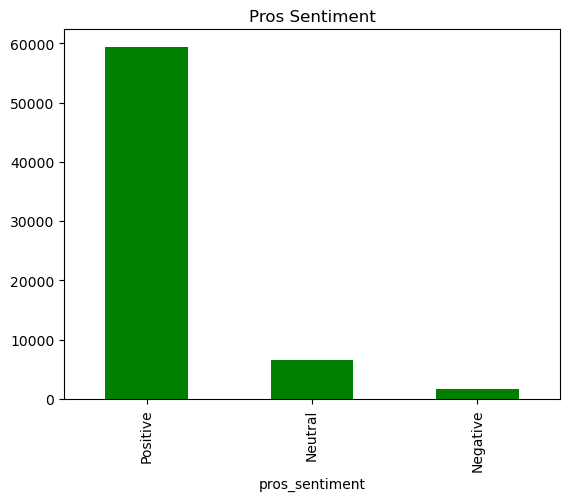

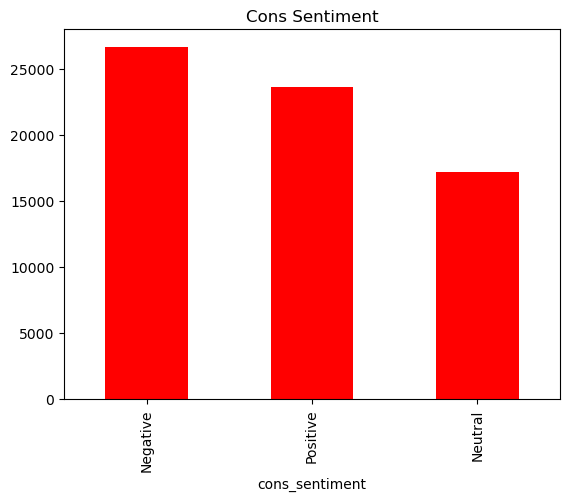

In [24]:
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()
def get_sentiment(text):
    score = sia.polarity_scores(str(text))  # convert to string just in case
    compound = score['compound']
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['pros_sentiment'] = df['pros'].apply(get_sentiment)
df['cons_sentiment'] = df['cons'].apply(get_sentiment)

# Quick check
print(df[['pros', 'pros_sentiment', 'cons', 'cons_sentiment']].head())

import matplotlib.pyplot as plt

# Count of sentiment in pros
df['pros_sentiment'].value_counts().plot(kind='bar', color='green', title='Pros Sentiment')
plt.savefig("C:/Users/USER/Desktop/TechProject/static/pros_sentiment.png")
plt.show()

# Count of sentiment in cons
df['cons_sentiment'].value_counts().plot(kind='bar', color='red', title='Cons Sentiment')
plt.savefig("C:/Users/USER/Desktop/TechProject/static/cons_sentiment.png")
plt.show()
